In [1]:
# ============================
# CELL 1: COMMON DEFINITIONS
# ============================
import torch
import torch.nn as nn
import torch.optim as optim
import time
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

# ===========================
# Reproducibility
# ===========================
torch.manual_seed(42)
torch.cuda.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ===========================
# Device
# ===========================
if torch.cuda.is_available():
  device = 'cuda'
  print(torch.cuda.get_device_name(0))
else:
  device = 'cpu'
print('using device:', device)
# ===========================
# PINN Model
# ===========================
LAYERS = 8
NEURONS = 256
class PINN(nn.Module):
    def __init__(self, layers=LAYERS, neurons=NEURONS):
        super().__init__()
        net = [nn.Linear(3, neurons), nn.Tanh()]
        for _ in range(layers - 1):
          net += [nn.Linear(neurons, neurons), nn.Tanh()]
        net += [nn.Linear(neurons, 1)]
        self.net = nn.Sequential(*net)
        self.initialize_weights()

    def initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

model = PINN().to(device)

# ===========================
# Hyperparameters
# ===========================
N_f = 10000       # collocation points
N_i = 5000       # initial condition points
T_final = 2 * np.pi   # one full rotation
adam_epochs = 20000
lbfgs_epochs  = 500

# Loss weights — w_ic higher because IC has sharp corners
w_pde  = 1.0
w_ic   = 10.0
w_eik  = 0.01

# ===========================
# Zalesak Geometry Parameters
# (from supervisor thesis, Chapter 7)
# ===========================
XC, YC = 0.5, 0.75   # disc center
R  = 0.15             # disc radius  (3/20)
W  = R / 6            # slot half-width  = 0.025
L  = R                # slot half-length = 0.15

SLOT_YCENTER = YC - 2 * W   # 0.70
SLOT_YMIN    = SLOT_YCENTER - L   # 0.55
SLOT_YMAX    = SLOT_YCENTER + L   # 0.85
# ===========================
# Velocity Field — solid body rotation
# u = -(y - 0.5),  v = (x - 0.5)
# divergence free, linear, T = 2pi => one full rotation
# ===========================
def velocity_field(x, y, t):
    u = -(y - 0.5)
    v =  (x - 0.5)
    return u, v

# ===========================
# Initial Condition — Zalesak slotted disc
# phi = max(phi_circle, -phi_slot)
# phi_circle < 0 inside disc
# phi_slot   < 0 inside slot
# Combined: inside disc but outside slot => phi < 0
# ===========================
def initial_condition(x, y):
    # Circle signed distance
    phi_circle = torch.sqrt((x - XC)**2 + (y - YC)**2) - R

    # Slot: rectangular region
    # width: |x - xc| <= W  =>  slot_x = |x - xc| - W
    # length: centered at yc - 2W, half-length L
    #   i.e.  |y - (yc - 2W)| <= L  =>  slot_y = |y - (yc-2W)| - L
    # phi_slot = max(slot_x, slot_y)
    # phi_slot < 0 means inside the slot rectangle
    slot_x = torch.abs(x - XC) - W
    slot_y = torch.abs(y - (YC - 2*W)) - L
    phi_slot = torch.maximum(slot_x, slot_y)

    # Slotted disc: inside disc AND outside slot
    # = max(phi_circle, -phi_slot)
    phi = torch.maximum(phi_circle, -phi_slot)
    return phi

# ===========================
# Sample Points
# ===========================
torch.manual_seed(100)
torch.cuda.manual_seed(100)

# Collocation points: (x, y, t) uniform in [0,1]^2 x [0,T]
X_f = torch.rand(N_f, 3, dtype=torch.float32, device=device).requires_grad_(True)

# IC points: (x, y) uniform in [0,1]^2, t=0
x_i = torch.rand(N_i, 1, dtype=torch.float32, device=device)
y_i = torch.rand(N_i, 1, dtype=torch.float32, device=device)
t_i = torch.zeros(N_i, 1, dtype=torch.float32, device=device)
X_i = torch.cat([x_i, y_i, t_i], dim=1)

print(f'Collocation points: {N_f}')
print(f'IC points:          {N_i}')
print(f'T_final:            {T_final:.4f} (2*pi = one full rotation)')
print(f'Loss weights:       pde={w_pde}, ic={w_ic}, eik={w_eik}')

# ===========================
# Loss Function
# ===========================
def physics_loss(X_f, X_i):
    # --- PDE Loss: phi_t + u*phi_x + v*phi_y = 0 ---
    phi = model(X_f)
    grad_phi = torch.autograd.grad(phi, X_f, grad_outputs=torch.ones_like(phi), create_graph=True)[0]
    phi_x = grad_phi[:, 0:1]
    phi_y = grad_phi[:, 1:2]
    phi_t = grad_phi[:, 2:3]

    u, v = velocity_field(X_f[:, 0:1], X_f[:, 1:2], X_f[:, 2:3])
    f_pde = phi_t + T_final * (u * phi_x + v * phi_y)
    loss_pde = torch.mean(f_pde**2)

    # --- IC Loss ---
    phi_pred = model(X_i)
    phi_true = initial_condition(X_i[:, 0:1], X_i[:, 1:2])
    loss_ic = torch.mean((phi_pred - phi_true)**2)

    # --- Eikonal Loss: |grad_phi| = 1 ---
    norm_phi = torch.sqrt(phi_x**2 + phi_y**2 + 1e-8)
    loss_eik = torch.mean((norm_phi - 1.0)**2)

    total_loss = w_pde * loss_pde + w_ic * loss_ic + w_eik * loss_eik
    return loss_pde, loss_ic, loss_eik, total_loss

Mounted at /content/drive
Tesla T4
using device: cuda
Collocation points: 10000
IC points:          5000
T_final:            6.2832 (2*pi = one full rotation)
Loss weights:       pde=1.0, ic=10.0, eik=0.01


In [2]:
# ========================
# Training
# ========================
optimizer_adam = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer_adam, step_size=1000, gamma=0.9)
start_time = time.time()
history = {'epoch': [], 'total': [], 'pde': [], 'ic': [], 'eik': []}
# Adam optimizer
for epoch in range(adam_epochs):
    optimizer_adam.zero_grad()
    loss_pde, loss_ic, loss_eik, loss = physics_loss(X_f, X_i)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer_adam.step()
    scheduler.step()
    lr = scheduler.get_last_lr()[0]

    history['epoch'].append(epoch)
    history['total'].append(loss.item())
    history['pde'].append(loss_pde.item())
    history['ic'].append(loss_ic.item())
    history['eik'].append(loss_eik.item())

    if epoch % 2000 == 0:
      print(f"Adam Iter {epoch} | total loss {loss.item():.3e} | pde loss {loss_pde.item():.3e} | ic loss {loss_ic.item():.3e} | eik loss {loss_eik.item():.3e} | LR {lr:.3e}")
    elif epoch == adam_epochs - 1:
      print(f"Adam Iter {adam_epochs} | total loss {loss.item():.3e} | pde loss {loss_pde.item():.3e} | ic loss {loss_ic.item():.3e} | eik loss {loss_eik.item():.3e} | LR {lr:.3e}")

# LBFGS training
print("LBFGS Optimizer Starting...")
optimizer_lbfgs = optim.LBFGS(model.parameters(), lr=1.0,  line_search_fn='strong_wolfe')
loss_store = {}
for epoch in range(lbfgs_epochs):
    def closure():
        optimizer_lbfgs.zero_grad()
        loss_pde, loss_ic, loss_eik, loss = physics_loss(X_f, X_i)
        loss.backward()
        loss_store['total'] = loss.item()
        loss_store['pde'] = loss_pde.item()
        loss_store['ic'] = loss_ic.item()
        loss_store['eik'] = loss_eik.item()
        return loss
    optimizer_lbfgs.step(closure)

    history['epoch'].append(adam_epochs + epoch)
    history['total'].append(loss_store['total'])
    history['pde'].append(loss_store['pde'])
    history['ic'].append(loss_store['ic'])
    history['eik'].append(loss_store['eik'])
    if epoch % 200 == 0:
      print(f"LBFGS epoch {epoch} | total loss {loss_store['total']:.3e} | pde loss {loss_store['pde']:.3e} | ic loss {loss_store['ic']:.3e} | eik loss {loss_store['eik']:.3e}")
    elif epoch == lbfgs_epochs - 1:
      print(f"LBFGS epoch {lbfgs_epochs} | total loss {loss_store['total']:.3e} | pde loss {loss_store['pde']:.3e} | ic loss {loss_store['ic']:.3e} | eik loss {loss_store['eik']:.3e}")
end_time = time.time()
total_training_time = (end_time - start_time)/60
print(f"Full training done in {total_training_time:.1f} minutes")

# Save checkpoint
checkpoint_path = '/content/drive/MyDrive/ZD_S1_exp03.pth'
torch.save({
    'model_state_dict':           model.state_dict(),
    'optimizer_adam_state_dict':  optimizer_adam.state_dict(),
    'optimizer_lbfgs_state_dict': optimizer_lbfgs.state_dict(),
    'training_time':              f'{total_training_time:.1f} minutes',
    'history':                    history
}, checkpoint_path)
print(f"Saved to {checkpoint_path}")

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Adam Iter 0 | total loss 3.254e+00 | pde loss 4.016e-01 | ic loss 2.849e-01 | eik loss 4.251e-01 | LR 1.000e-03
Adam Iter 2000 | total loss 1.995e-02 | pde loss 1.390e-02 | ic loss 4.398e-04 | eik loss 1.655e-01 | LR 8.100e-04
Adam Iter 4000 | total loss 8.291e-03 | pde loss 6.157e-03 | ic loss 1.469e-04 | eik loss 6.657e-02 | LR 6.561e-04
Adam Iter 6000 | total loss 1.516e-03 | pde loss 5.083e-04 | ic loss 6.242e-05 | eik loss 3.838e-02 | LR 5.314e-04
Adam Iter 8000 | total loss 1.146e-03 | pde loss 2.802e-04 | ic loss 5.494e-05 | eik loss 3.160e-02 | LR 4.305e-04
Adam Iter 10000 | total loss 2.004e-03 | pde loss 1.005e-03 | ic loss 7.183e-05 | eik loss 2.811e-02 | LR 3.487e-04
Adam Iter 12000 | total loss 8.769e-04 | pde loss 1.072e-04 | ic loss 5.205e-05 | eik loss 2.492e-02 | LR 2.824e-04
Adam Iter 14000 | total loss 8.623e-04 | pde loss 1.073e-04 | ic loss 5.251e-05 | eik loss 2.299e-02 | LR 2.288e-04
Adam Iter 16000 | total loss 7.770e-04 | pde loss 4.859e-05 | ic loss 5.152e-05 

In [3]:
# ===========================
# Load Model
# ===========================
checkpoint = torch.load('/content/drive/MyDrive/ZD_S1_exp03.pth', map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("Model Loaded Successfully!")

Model Loaded Successfully!


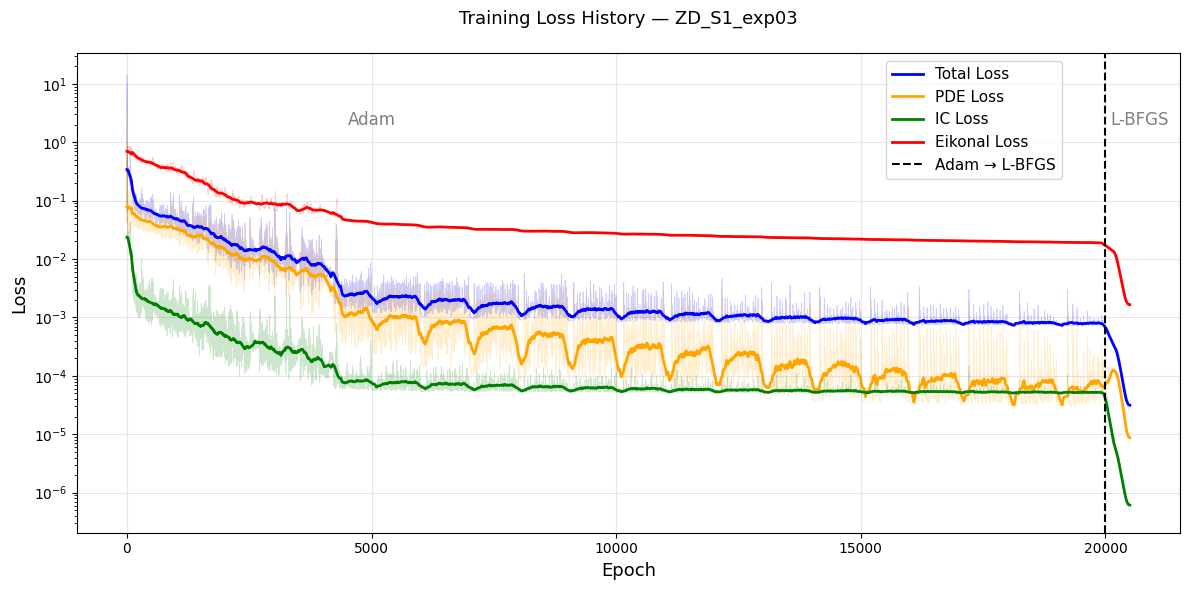

Saved


In [4]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import uniform_filter1d

history = checkpoint['history']
epochs = np.array(history['epoch'])
total  = np.array(history['total'])
pde    = np.array(history['pde'])
ic     = np.array(history['ic'])
eik    = np.array(history['eik'])

fig, ax = plt.subplots(figsize=(12, 6))

# Raw losses
colors = {'total': 'blue', 'pde': 'orange', 'ic': 'green', 'eik': 'red'}
ax.semilogy(epochs, total, color=colors['total'], alpha=0.2, linewidth=0.5)
ax.semilogy(epochs, pde,   color=colors['pde'],   alpha=0.2, linewidth=0.5)
ax.semilogy(epochs, ic,    color=colors['ic'],    alpha=0.2, linewidth=0.5)
ax.semilogy(epochs, eik,   color=colors['eik'],   alpha=0.2, linewidth=0.5)

# Smoothed trend lines
window = 200
for data, color, label in [
    (total, colors['total'], 'Total Loss'),
    (pde,   colors['pde'],   'PDE Loss'),
    (ic,    colors['ic'],    'IC Loss'),
    (eik,   colors['eik'],   'Eikonal Loss'),
]:
    log_smoothed = uniform_filter1d(
        np.log10(np.clip(data, 1e-12, None)), size=window
    )
    ax.semilogy(epochs, 10**log_smoothed, color=color, linewidth=2, label=label)

# Adam / LBFGS separator
ax.axvline(x=adam_epochs, color='black', linestyle='--',
           linewidth=1.5, label='Adam → L-BFGS')
ax.text(5000, 2.0,  'Adam',   fontsize=12, ha='center', color='black', alpha=0.5)
ax.text(20100, 2.0,  'L-BFGS', fontsize=12, ha='left',   color='black', alpha=0.5)

ax.set_xlabel('Epoch', fontsize=13)
ax.set_ylabel('Loss',  fontsize=13)
ax.set_title(
    'Training Loss History — ZD_S1_exp03\n',
    fontsize=13
)
ax.legend(fontsize=11, loc='upper right', bbox_to_anchor=(0.90, 1.00))
ax.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('/content/drive/MyDrive/fig_training_loss_ZD_S1_exp03.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved")

Self-check: max|rotated(t=0) - IC| = 1.29e-07  (must be ~0)


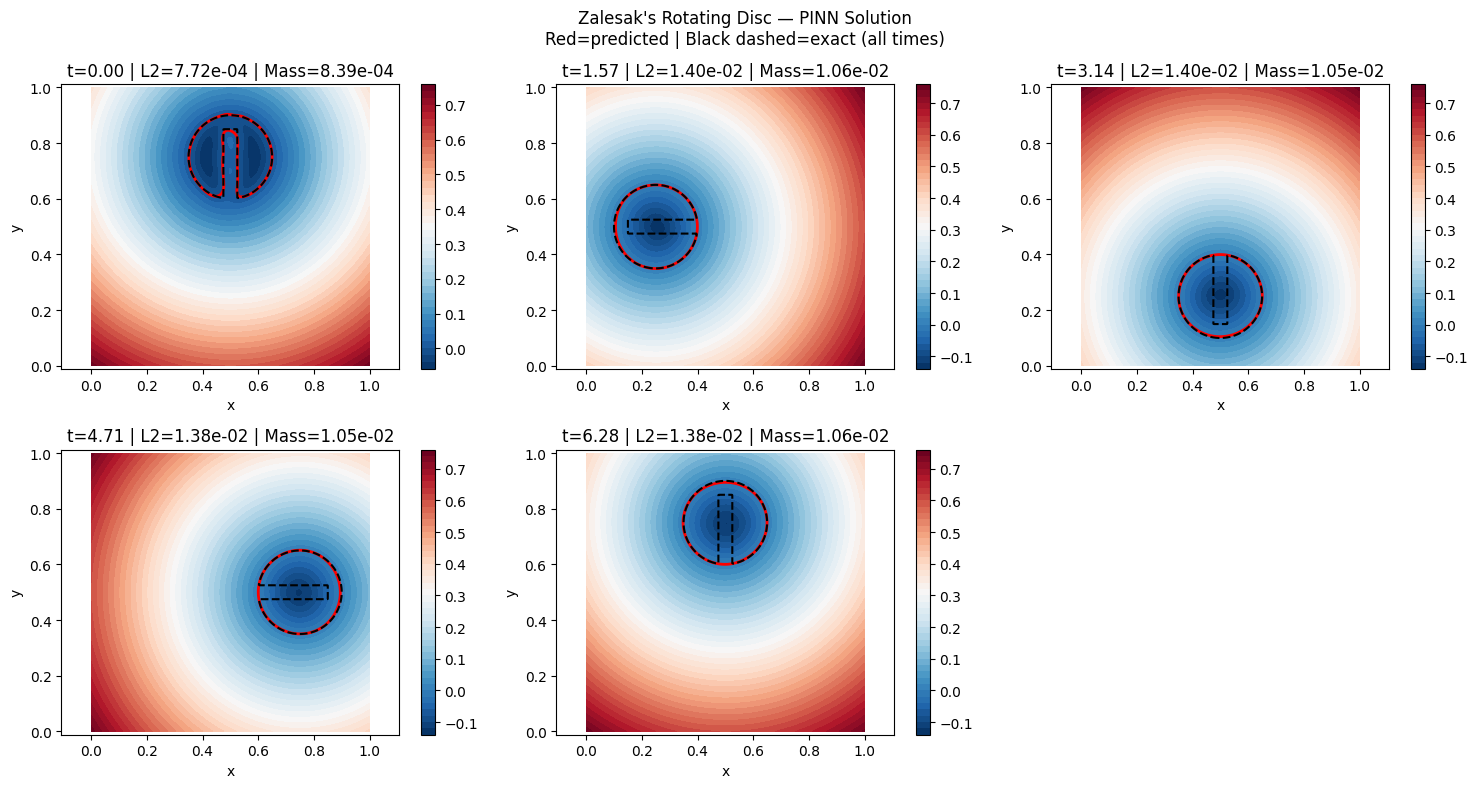


Snapshot       L2 Error   Mass Error
------------------------------------
t=0.00       7.7160e-04    8.3892e-04
t=1.57       1.3977e-02    1.0615e-02
t=3.14       1.3953e-02    1.0526e-02
t=4.71       1.3835e-02    1.0526e-02
t=6.28       1.3800e-02    1.0570e-02
------------------------------------
avg          1.1267e-02    8.6151e-03


In [5]:
# ============================
# CELL 4: VISUALIZATION
# ============================
import matplotlib.pyplot as plt

times = [0.0, T_final/4, T_final/2, 3*T_final/4, T_final]
nx    = 300

x  = np.linspace(0, 1, nx)
y  = np.linspace(0, 1, nx)
X, Y = np.meshgrid(x, y)
dx, dy = x[1]-x[0], y[1]-y[0]

def exact_phi_rotated(X, Y, t):
    theta  = 2 * np.pi * t / T_final
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    x0, y0 = 0.5, 0.5
    dx_c = XC - x0;  dy_c = YC - y0
    XC_t = x0 + cos_t*dx_c - sin_t*dy_c
    YC_t = y0 + sin_t*dx_c + cos_t*dy_c
    dX = X - XC_t;  dY = Y - YC_t
    X_loc =  cos_t*dX + sin_t*dY
    Y_loc = -sin_t*dX + cos_t*dY
    phi_circle = np.sqrt(dX**2 + dY**2) - R
    slot_x     = np.abs(X_loc) - W
    slot_y     = np.abs(Y_loc - (SLOT_YCENTER - YC)) - L
    phi_slot   = np.maximum(slot_x, slot_y)
    return np.maximum(phi_circle, -phi_slot)

def compute_errors(phi_pred, phi_ref, dx, dy):
    L2_error   = np.sqrt(np.mean((phi_pred - phi_ref)**2))
    mass_pred  = np.sum(phi_pred < 0) * dx * dy
    mass_ref   = np.sum(phi_ref  < 0) * dx * dy
    mass_error = abs(mass_pred - mass_ref)
    return L2_error, mass_error

# Self-check
phi_ref_t0 = exact_phi_rotated(X, Y, 0.0)
xt = torch.tensor(X.flatten(), dtype=torch.float32).unsqueeze(1)
yt = torch.tensor(Y.flatten(), dtype=torch.float32).unsqueeze(1)
with torch.no_grad():
    phi_ic_np = initial_condition(xt, yt).numpy().reshape(nx, nx)
print(f"Self-check: max|rotated(t=0) - IC| = {np.max(np.abs(phi_ref_t0 - phi_ic_np)):.2e}  (must be ~0)")

l2_errors, mass_errors = [], []
plt.figure(figsize=(15, 8))

for i, t_val in enumerate(times):
    t_norm = t_val / T_final
    XYT = torch.tensor(
        np.stack([X.flatten(), Y.flatten(),
                  t_norm * np.ones(X.size)], axis=1),
        dtype=torch.float32, device=device
    )
    with torch.no_grad():
        phi_pinn = model(XYT).cpu().numpy().reshape(nx, nx)

    phi_ref_t          = exact_phi_rotated(X, Y, t_val)
    L2_err, mass_err   = compute_errors(phi_pinn, phi_ref_t, dx, dy)
    l2_errors.append(L2_err)
    mass_errors.append(mass_err)

    plt.subplot(2, 3, i + 1)
    plt.contourf(X, Y, phi_pinn, levels=50, cmap='RdBu_r')
    plt.colorbar()
    plt.contour(X, Y, phi_pinn,  levels=[0], colors='red',
                linewidths=2)
    plt.contour(X, Y, phi_ref_t, levels=[0], colors='black',
                linewidths=1.5, linestyles='--')
    plt.title(f't={t_val:.2f} | L2={L2_err:.2e} | Mass={mass_err:.2e}')
    plt.xlabel('x'); plt.ylabel('y')
    plt.axis('equal')

plt.suptitle("Zalesak's Rotating Disc — PINN Solution\n"
             "Red=predicted | Black dashed=exact (all times)",
             fontsize=12)
plt.tight_layout()
# plt.savefig('/content/drive/MyDrive/fig_evaluation_ZD_S1_exp03.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'Snapshot':<10} {'L2 Error':>12} {'Mass Error':>12}")
print("-" * 36)
for t_val, l2, mass in zip(times, l2_errors, mass_errors):
    print(f"t={t_val:<7.2f}  {l2:>12.4e}  {mass:>12.4e}")
print("-" * 36)
print(f"{'avg':<10} {np.mean(l2_errors):>12.4e}  {np.mean(mass_errors):>12.4e}")

In [6]:
import csv

# CONFIG
EXP_ID           = 'ZD_S1_exp03'
BENCHMARK        = 'ZD'
SAMPLING         = 'uniform'
SCHEDULER        = 'StepLR'
SCHEDULER_PARAMS = 'step_1000_gamma_0.9'
T_NORMALIZED     = True
CSV_PATH         = '/content/drive/MyDrive/ZD_S1_eikonal_study.csv'

row = {
    'exp_id':           EXP_ID,
    'benchmark':        BENCHMARK,
    'N_f':              N_f,
    'N_i':              N_i,
    'layers':           LAYERS,
    'neurons':          NEURONS,
    'w_pde':            w_pde,
    'w_ic':             w_ic,
    'w_eik':            w_eik,
    'adam_epochs':      adam_epochs,
    'lbfgs_epochs':     lbfgs_epochs,
    'scheduler':        SCHEDULER,
    'scheduler_params': SCHEDULER_PARAMS,
    'sampling':         SAMPLING,
    't_normalized':     T_NORMALIZED,
    'L2_t0':            f'{l2_errors[0]:.4e}',
    'L2_tT':            f'{l2_errors[-1]:.4e}',
    'avg_L2':           f'{np.mean(l2_errors):.4e}',
    'mass_t0':          f'{mass_errors[0]:.4e}',
    'mass_tT':          f'{mass_errors[-1]:.4e}',
    'avg_mass':         f'{np.mean(mass_errors):.4e}',
    'training_time':    checkpoint['training_time']
}

with open(CSV_PATH, 'a', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=row.keys())
    if f.tell() == 0:
        writer.writeheader()
    writer.writerow(row)

print(f'Row appended → {CSV_PATH}')

Row appended → /content/drive/MyDrive/ZD_S1_eikonal_study.csv
